# perform_block_matching

Write a Python3 function `perform_block_matching(image_left, image_right, block_size, max_disparity)` which performs and returns the best disparity map using the block matching algorithm taught in CompSci773 lecture and tutorial. The function arguments 'image_left' and 'image_right' are a Python3 Numpy list of lists for the left image and the right image, taken from the two cameras. You may assume the left image and right image have been rectified. The function argument 'block_size' is the block size in the block matching algorithm, while 'max_disparity' is the maximum possible disparity value.

Your function should return a Python3 list of lists containing the computed disparity map with the same height and width as the left and right images. To do that, you need to implement the correct image border handling. In this question, you should extend the border by padding with boundary values of the input image (BorderBoundaryPadding). To do that, you may use our helper function 'reflect_make_border(image, offset)' to perform border padding and acquire the padded image. Function argument 'image' is your input image, and 'offset' is the padding width (offset = block_size // 2). You need to do that for both left and right images. Then, before you return the computed disparity map, you need to remove the padded regions to preserve the original image size.

For Block-Score (x, y, d) discussed in the lecture and tutorial, you should use NCC (Normalized Cross Correlation) to compute the cost between two blocks in the left and right images. You may use our helper function 'ncc_cost(block_left, block_right)' to compute NCC as well. The function arguments 'block_left' and 'block_right' are the left and right image windows, respectively.

Note: Do not round your results in any way!

Note: Do not perform any normalization on your disparity map!

Note: You may assume the Python module "Numpy" is available.

Note: You may download the following left and right images to test your code on your own code editor!

Click Here to Download Left Image, Click Here to Download Right Image

Note: You may also download the expected disparity map (in .npy format) below. To read the .npy file, use the following code: np.load('disparity_map.npy').

Click Here to Download Data



In [1]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [3]:
def ncc_cost(block_left, block_right):
    # Implementation for Normalized Cross-Correlation cost
    nom_left = block_left - np.mean(block_left)
    nom_right = block_right - np.mean(block_right)
    numerator = np.sum(nom_left * nom_right)
    denominator = np.sqrt(np.sum(nom_left ** 2) * np.sum(nom_right ** 2))
    if denominator == 0:
        return 0
    return numerator / denominator

In [4]:
def reflect_make_border(image, offset):
    # extend the border by padding with boundary values of the input image
    return np.pad(image, ((offset, offset), (offset, offset)), mode='edge')

In [13]:

def perform_block_matching(image_left, image_right, block_size, max_disparity, debug_x=None, debug_y=None):
    debug = debug_x is not None and debug_y is not None
    height, width = image_left.shape
    offset = block_size // 2
    
    # print(f"offset: {offset}")
    
    # Extend the border by padding with boundary values
    padded_left = reflect_make_border(image_left, offset)
    padded_right = reflect_make_border(image_right, offset)
    
    # Initialize the disparity map
    disparity_map = np.zeros((height, width), dtype=int)
    
    # Iterate over every pixel in the original img
    for h in range(height):
        for w in range(width):
            # Map coordinates to the padded img
            y = h + offset
            x = w + offset
            
            best_score = -float('inf')
            best_disparity = 0
            
            # Extract left img reference block
            block_left = padded_left[y - offset : y + offset + 1, x - offset : x + offset + 1]
            
            if debug and h == debug_y and w == debug_x:
                print(f"Debugging pixel at (row={h}, col={w})")
                print(f"Reference block from left image:\n{block_left}")
                print("\n"+"-"*50+"\n")

            # Evaluate 0 => max_disparity
            for d in range(max_disparity + 1):
                x_right = x - d
                
                # Stop if outside the padded boundary
                if x_right - offset < 0:
                    break
                    
                # right img corresponding block
                block_right = padded_right[y - offset : y + offset + 1, x_right - offset : x_right + offset + 1]
                
                if debug and h == debug_y and w == debug_x:
                    print(f"Corresponding block from right image:\n{block_right}")
                    print("\n"+"-"*10+"\n")

                # Compute NCC
                score = ncc_cost(block_left, block_right)

                # best disparity
                if score > best_score:
                    best_score = score
                    best_disparity = d
                    
                if debug and h == debug_y and w == debug_x:
                    print(f"Disparity {d}: NCC Score = {score}")
                    print(f"Current best disparity: {best_disparity} with score {best_score}\n")
            
            # Store the best disparity to return
            disparity_map[h, w] = best_disparity
            
    # Return as a native Python list of lists
    return disparity_map.tolist()

In [6]:
Il = np.array(
    [
        [117, 31, 80, 81, 99, 68, 69],
        [102, 83, 92, 46, 90, 62, 54],
        [73, 88, 95, 99, 38, 44, 54],
        [61, 32, 22, 24, 25, 28, 35],
        [37, 51, 59, 58, 58, 62, 71],
        [70, 26, 31, 34, 38, 41, 49],
        [191, 178, 192, 177, 179, 179, 175],
    ]
)

Ir = np.array(
    [
        [114, 100, 85, 44, 99, 85, 59],
        [82, 60, 91, 47, 95, 63, 54],
        [67, 50, 90, 49, 39, 44, 54],
        [54, 31, 21, 24, 25, 27, 36],
        [38, 55, 59, 59, 58, 63, 71],
        [63, 17, 33, 37, 37, 42, 49],
        [187, 177, 188, 177, 178, 176, 173],
    ]
)

perform_block_matching(Il, Ir, block_size=3, max_disparity=5)

[[0, 0, 2, 0, 2, 0, 5],
 [0, 0, 0, 0, 0, 0, 1],
 [0, 0, 0, 0, 0, 0, 0],
 [0, 0, 1, 1, 1, 0, 0],
 [0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0]]

Rectified Left Image Shape: (50, 191)
Rectified Right Image Shape: (50, 191)


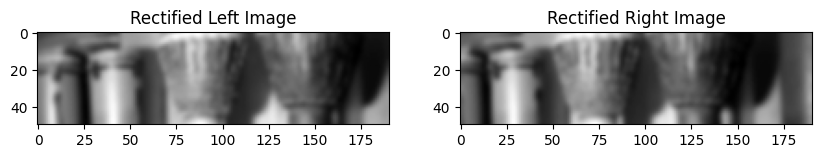

In [7]:
rectified_left_image = np.array(Image.open("./assets/block_matching/Djembe_left.png").convert('L'))
rectified_right_image = np.array(Image.open("./assets/block_matching/Djembe_right.png").convert('L'))

print("Rectified Left Image Shape:", rectified_left_image.shape)
print("Rectified Right Image Shape:", rectified_right_image.shape)

# show the rectified images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Rectified Left Image")
plt.imshow(rectified_left_image, cmap='gray')
plt.subplot(1, 2, 2)
plt.title("Rectified Right Image")
plt.imshow(rectified_right_image, cmap='gray')
plt.show()  

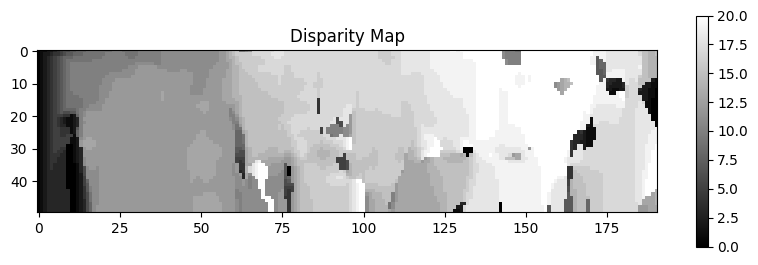

array([[ 0,  1,  1, ..., 14, 14, 15],
       [ 0,  1,  2, ..., 14, 14, 15],
       [ 0,  1,  2, ..., 14, 14, 14],
       ...,
       [ 0,  1,  2, ..., 13, 13, 14],
       [ 0,  1,  2, ..., 13, 13, 13],
       [ 0,  1,  2, ..., 13, 13, 13]], shape=(50, 191))

In [8]:
block_size = 11
max_disparity = 20
disparity_map = perform_block_matching(rectified_left_image, rectified_right_image, block_size=block_size, max_disparity=max_disparity)

# show the disparity map
plt.figure(figsize=(10, 3))
plt.title("Disparity Map")
plt.imshow(disparity_map, cmap='gray')
plt.colorbar()
plt.show()

disparity_map_np = np.array(disparity_map)
disparity_map_np

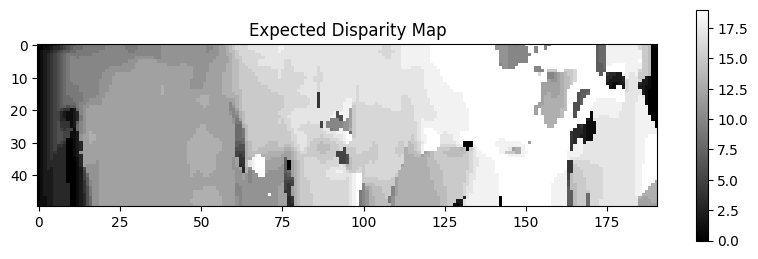

array([[ 0,  0,  0, ..., 14,  0,  0],
       [ 0,  0,  1, ..., 14,  0,  0],
       [ 0,  1,  2, ..., 14,  0,  0],
       ...,
       [ 0,  1,  1, ..., 13, 13, 13],
       [ 0,  1,  1, ..., 12, 13, 13],
       [ 0,  1,  1, ..., 12, 12, 12]], shape=(50, 191))

In [9]:
expected_disparity_map = np.load("./assets/block_matching/disparity_map.npy")

# show the expected disparity map
plt.figure(figsize=(10, 3))
plt.title("Expected Disparity Map")
plt.imshow(expected_disparity_map, cmap='gray')
plt.colorbar()
plt.show()

expected_disparity_map

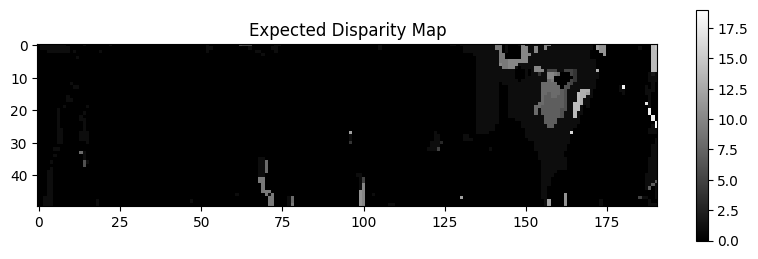

In [10]:
diff = np.abs(disparity_map - expected_disparity_map)
# show the expected disparity map
plt.figure(figsize=(10, 3))
plt.title("Expected Disparity Map")
plt.imshow(diff, cmap='gray')
plt.colorbar()
plt.show()

# Debug

In [11]:
# first mismatch position
mismatch_positions = np.argwhere(diff != 0)
if mismatch_positions.size > 0:
    first_mismatch = mismatch_positions[0]
    print("First mismatch position (row, col):", first_mismatch)
else:
    print("No mismatches found.")

First mismatch position (row, col): [0 1]


In [14]:
# show step by step calculation for the first mismatch
first_h, first_w = first_mismatch

print(f"First 5 top left corner of the left image:\n{rectified_left_image[:5, :5]}")

print("\n" + "=" * 50 + "\n")

disparity_map = perform_block_matching(rectified_left_image, rectified_right_image, block_size=block_size, max_disparity=max_disparity, debug_x=first_w, debug_y=first_h)

First 5 top left corner of the left image:
[[67 67 67 68 70]
 [66 67 68 70 73]
 [68 69 71 74 77]
 [72 73 76 79 83]
 [77 78 81 85 89]]


Debugging pixel at (row=0, col=1)
Reference block from left image:
[[67 67 67 67 67 67 67 68 70 71 73]
 [67 67 67 67 67 67 67 68 70 71 73]
 [67 67 67 67 67 67 67 68 70 71 73]
 [67 67 67 67 67 67 67 68 70 71 73]
 [67 67 67 67 67 67 67 68 70 71 73]
 [67 67 67 67 67 67 67 68 70 71 73]
 [66 66 66 66 66 67 68 70 73 75 77]
 [68 68 68 68 68 69 71 74 77 80 83]
 [72 72 72 72 72 73 76 79 83 86 89]
 [77 77 77 77 77 78 81 85 89 91 94]
 [82 82 82 82 82 84 86 89 92 94 96]]

--------------------------------------------------

Corresponding block from right image:
[[ 83  83  83  83  83  84  85  87  88  91  93]
 [ 83  83  83  83  83  84  85  87  88  91  93]
 [ 83  83  83  83  83  84  85  87  88  91  93]
 [ 83  83  83  83  83  84  85  87  88  91  93]
 [ 83  83  83  83  83  84  85  87  88  91  93]
 [ 83  83  83  83  83  84  85  87  88  91  93]
 [ 89  89  89  89  89  89  

In [16]:
first_block = np.array(
    [
        [67, 67, 67, 67, 67, 67, 67, 68, 70, 71, 73],
        [67, 67, 67, 67, 67, 67, 67, 68, 70, 71, 73],
        [67, 67, 67, 67, 67, 67, 67, 68, 70, 71, 73],
        [67, 67, 67, 67, 67, 67, 67, 68, 70, 71, 73],
        [67, 67, 67, 67, 67, 67, 67, 68, 70, 71, 73],
        [67, 67, 67, 67, 67, 67, 67, 68, 70, 71, 73],
        [66, 66, 66, 66, 66, 67, 68, 70, 73, 75, 77],
        [68, 68, 68, 68, 68, 69, 71, 74, 77, 80, 83],
        [72, 72, 72, 72, 72, 73, 76, 79, 83, 86, 89],
        [77, 77, 77, 77, 77, 78, 81, 85, 89, 91, 94],
        [82, 82, 82, 82, 82, 84, 86, 89, 92, 94, 96],
    ]
)

second_block = np.array(
    [
        [83, 83, 83, 83, 83, 83, 84, 85, 87, 88, 91],
        [83, 83, 83, 83, 83, 83, 84, 85, 87, 88, 91],
        [83, 83, 83, 83, 83, 83, 84, 85, 87, 88, 91],
        [83, 83, 83, 83, 83, 83, 84, 85, 87, 88, 91],
        [83, 83, 83, 83, 83, 83, 84, 85, 87, 88, 91],
        [83, 83, 83, 83, 83, 83, 84, 85, 87, 88, 91],
        [89, 89, 89, 89, 89, 89, 89, 91, 92, 94, 96],
        [94, 94, 94, 94, 94, 94, 95, 96, 97, 98, 100],
        [98, 98, 98, 98, 98, 98, 98, 99, 100, 100, 102],
        [100, 100, 100, 100, 100, 100, 100, 100, 101, 101, 102],
        [101, 101, 101, 101, 101, 101, 101, 101, 102, 102, 101],
    ]
)

# re-calculate NCC scores between the first block and the second block
nom_first_block = first_block - np.mean(first_block)
nom_second_block = second_block - np.mean(second_block)
numerator = np.sum(nom_first_block * nom_second_block)
denominator = np.sqrt(np.sum(nom_first_block**2) * np.sum(nom_second_block**2))
print(f"Numerator: {numerator}")
print(f"Denominator: {denominator}")
ncc_score = numerator / denominator if denominator != 0 else 0
print(
    f"Re-calculated NCC score between the first block and the second block: {ncc_score}"
)

Numerator: 5333.99173553719
Denominator: 6290.063079613975
Re-calculated NCC score between the first block and the second block: 0.8480029004517615
